In [2]:
import pandas as pd 
import numpy as np
import os

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import os
import pandas as pd

# Corrected file paths based on your directory structure
train_aug_dataset_path = os.path.join('..', 'data_process', 'processed_data', 'train_with_data_augmentation.csv')
train_no_aug_dataset_path = os.path.join('..', 'data_process', 'processed_data', 'train_without_data_augmentation.csv')

# Load the datasets
aug_df = pd.read_csv(train_aug_dataset_path)
no_aug_df = pd.read_csv(train_no_aug_dataset_path)


In [3]:
train_aug_dataset_path = os.path.join('..', 'data_process', 'processed_threshold', 'train_with_data_augmentation.csv')
train_no_aug_dataset_path = os.path.join('..', 'data_process', 'processed_threshold', 'train_without_data_augmentation.csv')
aug_df = pd.read_csv(train_aug_dataset_path)
no_aug_df = pd.read_csv(train_no_aug_dataset_path)



FileNotFoundError: [Errno 2] No such file or directory: '../data_process/processed_threshold/train_with_data_augmentation.csv'

In [5]:
aug_df.info()
no_aug_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108380 entries, 0 to 108379
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   SMILES  108380 non-null  object 
 1   MP      108380 non-null  float64
 2   Type    108380 non-null  object 
dtypes: float64(1), object(2)
memory usage: 2.5+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17633 entries, 0 to 17632
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SMILES  17633 non-null  object 
 1   MP      17633 non-null  float64
 2   Type    17633 non-null  object 
dtypes: float64(1), object(2)
memory usage: 413.4+ KB


In [6]:
def calculate_quantile(choose_df):
    q1 = choose_df['MP'].quantile(0.25)
    q3 = choose_df['MP'].quantile(0.75)
    return q1, q3

q1_aug, q3_aug = calculate_quantile(aug_df)
q1_no_aug, q3_no_aug = calculate_quantile(no_aug_df)
print("First Quartile_Aug:", q1_aug, "Third Quartile_Aug:", q3_aug)
print("First Quartile_No_Aug:", q1_no_aug,"Third Quartile_No_Aug:", q3_no_aug)

First Quartile_Aug: 76.0 Third Quartile_Aug: 194.0
First Quartile_No_Aug: 47.0 Third Quartile_No_Aug: 167.0


In [7]:
def mp_quantile_cat(mp, q1, q3):
    conditions = [mp < q1, mp > q3]
    choices = ['Low', 'High']
    result = np.select(conditions, choices, default = 'Intermediate')
    return result

aug_df['MP_category_quant'] = mp_quantile_cat(aug_df['MP'], q1_aug, q3_aug)
no_aug_df['MP_category_quant'] = mp_quantile_cat(no_aug_df['MP'], q1_no_aug, q3_no_aug)

aug_df

,SMILES,MP,Type,MP_category_quant
0,CC1(C)CCCC1,-70.0,train_with_data_augmentation,Low
1,[CH3][C]1([CH3])[CH2][CH2][CH2][CH2]1,-70.0,train_with_data_augmentation,Low
2,c1ccc(cc1)C#Cc1ccc(cc1)C#Cc1ccccc1,177.0,train_with_data_augmentation,Intermediate
3,C(#CC1=CC=C(C#CC2=CC=CC=C2)C=C1)C1=CC=CC=C1,177.0,train_with_data_augmentation,Intermediate
4,C(#Cc1ccc(C#Cc2ccccc2)cc1)c1ccccc1,177.0,train_with_data_augmentation,Intermediate
...,...,...,...,...
108375,CC(O)=CC(=O)Nc1ccc(-c2ccc(NC(=O)C=C(C)O)c(C)c2...,212.0,train_with_data_augmentation,High
108376,CC(O)=CC(O)=Nc1ccc(-c2ccc(N=C(O)C=C(C)O)c(C)c2...,212.0,train_with_data_augmentation,High
108377,CCCCCCCCCCCCCCCC(=O)OCCCC,16.9,train_with_data_augmentation,Low
108378,[CH3][CH2][CH2][CH2][CH2][CH2][CH2][CH2][CH2][...,16.9,train_with_data_augmentation,Low


In [8]:
def mp_drug_region_cat(mp):
    conditions = [mp < 50, mp > 250]
    choices = ['Low', 'High']
    result = np.select(conditions, choices, default = 'Intermediate')
    return result

aug_df['MP_category_drug_region'] = mp_drug_region_cat(aug_df['MP'])
no_aug_df['MP_category_drug_region'] = mp_drug_region_cat(no_aug_df['MP'])

aug_df

,SMILES,MP,Type,MP_category_quant,MP_category_drug_region
0,CC1(C)CCCC1,-70.0,train_with_data_augmentation,Low,Low
1,[CH3][C]1([CH3])[CH2][CH2][CH2][CH2]1,-70.0,train_with_data_augmentation,Low,Low
2,c1ccc(cc1)C#Cc1ccc(cc1)C#Cc1ccccc1,177.0,train_with_data_augmentation,Intermediate,Intermediate
3,C(#CC1=CC=C(C#CC2=CC=CC=C2)C=C1)C1=CC=CC=C1,177.0,train_with_data_augmentation,Intermediate,Intermediate
4,C(#Cc1ccc(C#Cc2ccccc2)cc1)c1ccccc1,177.0,train_with_data_augmentation,Intermediate,Intermediate
...,...,...,...,...,...
108375,CC(O)=CC(=O)Nc1ccc(-c2ccc(NC(=O)C=C(C)O)c(C)c2...,212.0,train_with_data_augmentation,High,Intermediate
108376,CC(O)=CC(O)=Nc1ccc(-c2ccc(N=C(O)C=C(C)O)c(C)c2...,212.0,train_with_data_augmentation,High,Intermediate
108377,CCCCCCCCCCCCCCCC(=O)OCCCC,16.9,train_with_data_augmentation,Low,Low
108378,[CH3][CH2][CH2][CH2][CH2][CH2][CH2][CH2][CH2][...,16.9,train_with_data_augmentation,Low,Low


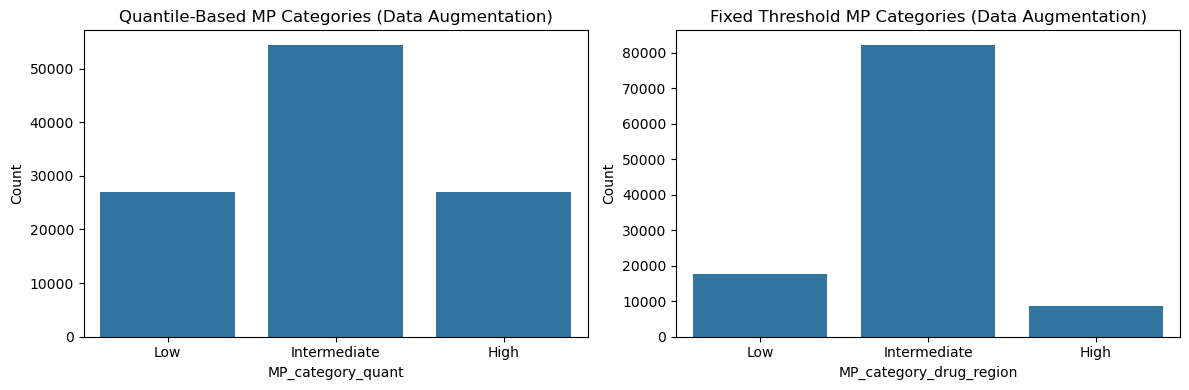

In [ ]:
plt.figure(figsize=(12, 4))

# Quantile-based
plt.subplot(1, 2, 1)
sns.countplot(x='MP_category_quant', data=aug_df, order=['Low', 'Intermediate', 'High'])
plt.title('Quantile-Based MP Categories (Data Augmentation)')
plt.ylabel('Count')

# Fixed thresholds
plt.subplot(1, 2, 2)
sns.countplot(x='MP_category_drug_region', data=aug_df, order=['Low', 'Intermediate', 'High'])
plt.title('Fixed Threshold MP Categories (Data Augmentation)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


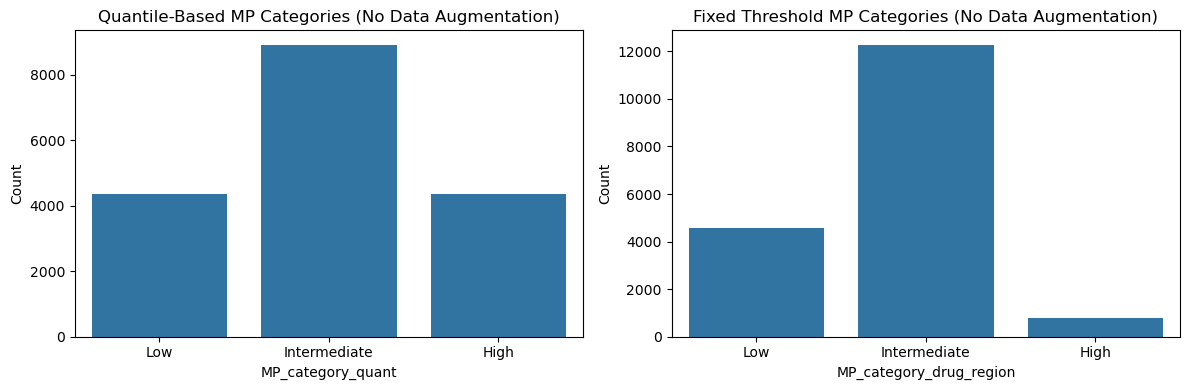

In [10]:
plt.figure(figsize=(12, 4))

# Quantile-based
plt.subplot(1, 2, 1)
sns.countplot(x='MP_category_quant', data=no_aug_df, order=['Low', 'Intermediate', 'High'])
plt.title('Quantile-Based MP Categories (No Data Augmentation)')
plt.ylabel('Count')

# Fixed thresholds
plt.subplot(1, 2, 2)
sns.countplot(x='MP_category_drug_region', data=no_aug_df, order=['Low', 'Intermediate', 'High'])
plt.title('Fixed Threshold MP Categories (No Data Augmentation)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


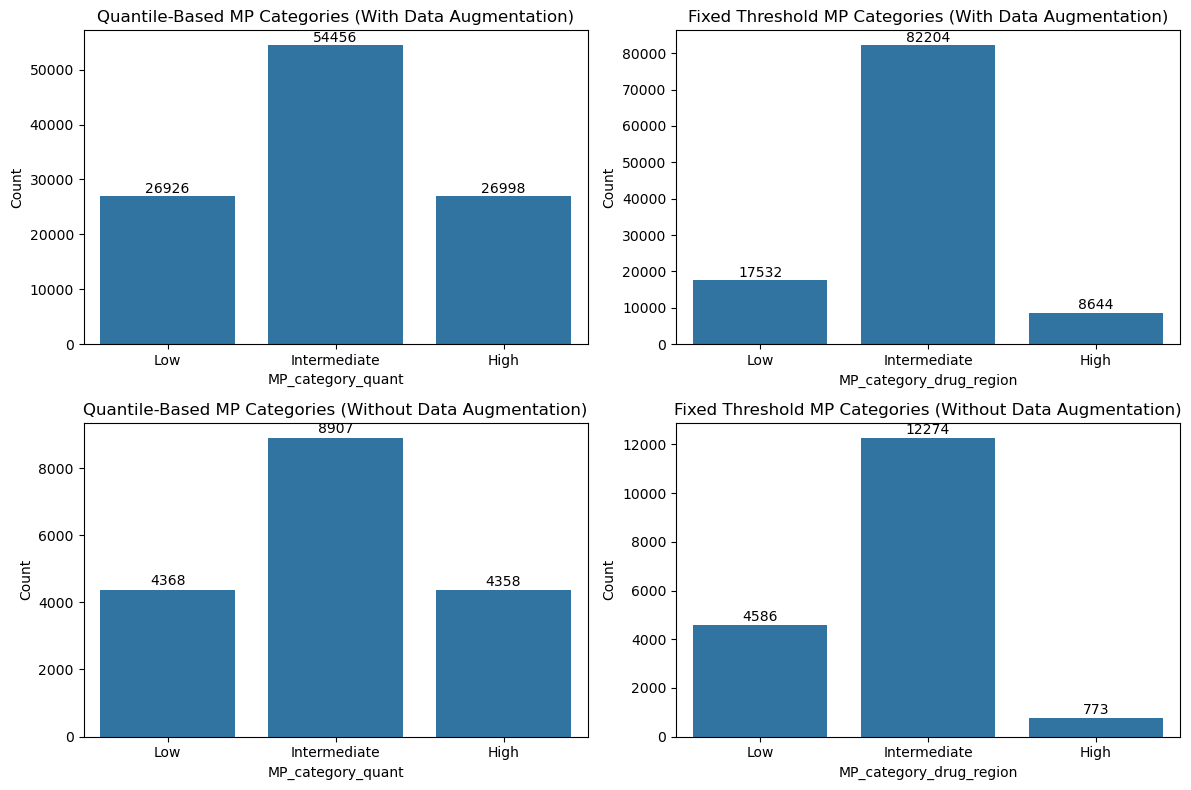

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# === 1. Data Augmentation ===
plt.subplot(2, 2, 1)
ax1 = sns.countplot(x='MP_category_quant', data=aug_df, order=['Low', 'Intermediate', 'High'])
plt.title('Quantile-Based MP Categories (With Data Augmentation)')
plt.ylabel('Count')

# Add counts above each bar
for p in ax1.patches:
    ax1.text(p.get_x() + p.get_width()/2,
             p.get_height() + 50,
             f'{int(p.get_height())}',
             ha='center', va='bottom', fontsize=10)

plt.subplot(2, 2, 2)
ax2 = sns.countplot(x='MP_category_drug_region', data=aug_df, order=['Low', 'Intermediate', 'High'])
plt.title('Fixed Threshold MP Categories (With Data Augmentation)')
plt.ylabel('Count')

for p in ax2.patches:
    ax2.text(p.get_x() + p.get_width()/2,
             p.get_height() + 50,
             f'{int(p.get_height())}',
             ha='center', va='bottom', fontsize=10)

# === 2. Non–Data Augmentation ===
plt.subplot(2, 2, 3)
ax3 = sns.countplot(x='MP_category_quant', data=no_aug_df, order=['Low', 'Intermediate', 'High'])
plt.title('Quantile-Based MP Categories (Without Data Augmentation)')
plt.ylabel('Count')

for p in ax3.patches:
    ax3.text(p.get_x() + p.get_width()/2,
             p.get_height() + 50,
             f'{int(p.get_height())}',
             ha='center', va='bottom', fontsize=10)

plt.subplot(2, 2, 4)
ax4 = sns.countplot(x='MP_category_drug_region', data=no_aug_df, order=['Low', 'Intermediate', 'High'])
plt.title('Fixed Threshold MP Categories (Without Data Augmentation)')
plt.ylabel('Count')

for p in ax4.patches:
    ax4.text(p.get_x() + p.get_width()/2,
             p.get_height() + 50,
             f'{int(p.get_height())}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


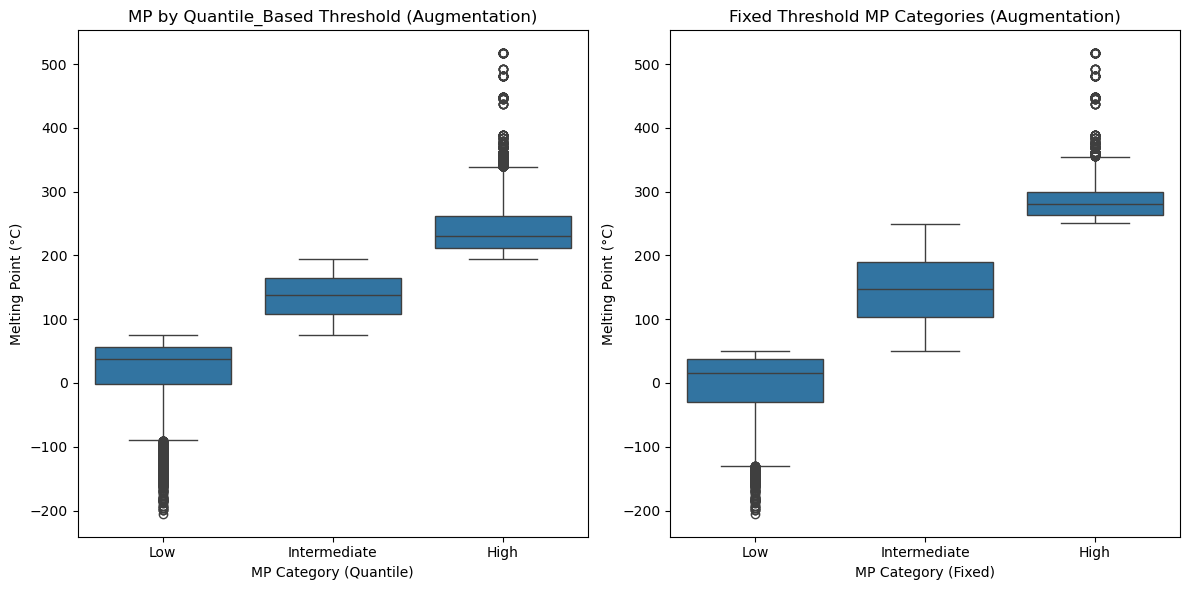

In [75]:
plt.figure(figsize=(12,6))

#Quantile-Based
plt.subplot(1, 2, 1)
sns.boxplot(x='MP_category_quant', y='MP', data = aug_df, order = ['Low', 'Intermediate', 'High'])
plt.title('MP by Quantile_Based Threshold (Augmentation)')
plt.ylabel('Melting Point (°C)')
plt.xlabel('MP Category (Quantile)')

#Fixed Thresholds
plt.subplot(1, 2, 2)
sns.boxplot(x='MP_category_drug_region', y='MP', data = aug_df, order = ['Low', 'Intermediate', 'High'])
plt.title('Fixed Threshold MP Categories (Augmentation)')
plt.ylabel('Melting Point (°C)')
plt.xlabel('MP Category (Fixed)')

plt.tight_layout()
plt.show()

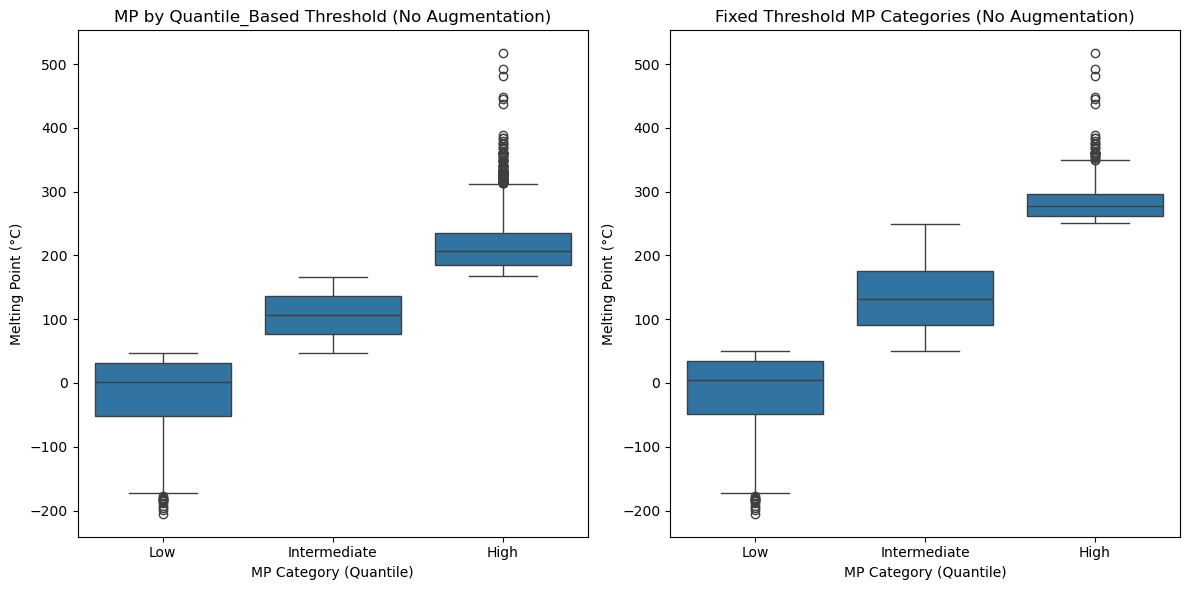

In [ ]:
plt.figure(figsize=(12,6))

#Quantile-Based
plt.subplot(1, 2, 1)
sns.boxplot(x='MP_category_quant', y='MP', data = no_aug_df, order = ['Low', 'Intermediate', 'High'])
plt.title('MP by Quantile_Based Threshold (No Augmentation)')
plt.ylabel('Melting Point (°C)')
plt.xlabel('MP Category (Quantile)')

#Fixed Thresholds
plt.subplot(1, 2, 2)
sns.boxplot(x='MP_category_drug_region', y='MP', data = no_aug_df, order = ['Low', 'Intermediate', 'High'])
plt.title('Fixed Threshold MP Categories (No Augmentation)')
plt.ylabel('Melting Point (°C)')
plt.xlabel('MP Category (Quantile)')

plt.tight_layout()
plt.show()